# 融资买入批次收益代理分析

首个交易日按全市场融资买入额确定累计 80% 的固定样本；样本以 BaoStock 基础信息标注证券类型，后续交易日不换样。

## 指标定义与适用边界

- 每个证券交易日的正融资买入额视为一个独立融资买入批次，并以融资买入额作为汇总权重。
- 买入价使用该证券当日全市场成交金额除以成交量得到的成交均价近似，再按前复权比例换算；这不是融资账户的真实成交价。
- 每个批次假设从买入日持续持有至相应评价日，以评价日前复权收盘价计算收益代理。代理正收益资金占比 = 代理收益大于 0 的批次融资买入额之和 / 纳入口径的全部批次融资买入额之和。
- 未建模融资偿还、强制平仓或主动卖出，也未扣除融资利息、交易费用和市场冲击成本。结果不是投资者账户级真实持仓盈亏，也不是可交易策略收益。

In [1]:
import os
import sys
import tempfile
from pathlib import Path

os.environ.setdefault('MPLCONFIGDIR', str(Path(tempfile.gettempdir()) / 'mme-matplotlib'))

import matplotlib.pyplot as plt
import pandas as pd
from matplotlib import font_manager
from matplotlib.ticker import PercentFormatter

ROOT = Path.cwd()
if not (ROOT / 'data').exists():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from mme.margin.profitability import (
    build_positions,
    compare_rolling_selection,
    calculate_cumulative_profitability,
    calculate_industry_cumulative_profitability,
    calculate_rolling_industry_profitability,
    calculate_rolling_profitability,
    calculate_sample_coverage,
    calculate_tier_profitability,
    prepare_security_metadata,
    select_rolling_securities,
)

SOURCE = ROOT / 'data/source/margin'
DERIVED = ROOT / 'data/derived/margin'

chinese_font_candidates = ['PingFang SC', 'Heiti SC', 'Hiragino Sans GB', 'STHeiti']
installed_fonts = {font.name for font in font_manager.fontManager.ttflist}
chinese_font = next((font for font in chinese_font_candidates if font in installed_fonts), None)
if chinese_font is None:
    raise RuntimeError('未找到可用中文字体，请安装 PingFang SC、Heiti SC 或 Hiragino Sans GB 后重试。')

plt.rcParams['font.sans-serif'] = [chinese_font]
plt.rcParams['axes.unicode_minus'] = False
print(f'使用中文字体：{chinese_font}')

使用中文字体：PingFang SC


In [2]:
margin_path = SOURCE / 'margin_financing_buy.parquet'
sample_path = DERIVED / 'first_day_top80.parquet'
prices_path = SOURCE / 'first_day_top80_prices.parquet'
tiers_path = DERIVED / 'first_day_financing_tiers.parquet'
tier_prices_path = SOURCE / 'first_day_financing_tier_prices.parquet'
basics_path = ROOT / 'data/source/security/baostock_security_basics.parquet'
industries_path = ROOT / 'data/source/security/baostock_security_industries.parquet'
for path in [margin_path, sample_path, prices_path, tiers_path, tier_prices_path, basics_path, industries_path]:
    if not path.exists():
        raise FileNotFoundError(f'缺少输入文件：{path}')

margin = pd.read_parquet(margin_path)
sample = pd.read_parquet(sample_path)
prices = pd.read_parquet(prices_path)
tiers = pd.read_parquet(tiers_path)
tier_prices = pd.read_parquet(tier_prices_path)
basics = pd.read_parquet(basics_path)
industries = pd.read_parquet(industries_path)
margin['trade_date'] = pd.to_datetime(margin['trade_date'])
sample['trade_date'] = pd.to_datetime(sample['trade_date'])
prices['trade_date'] = pd.to_datetime(prices['trade_date'])
tiers['trade_date'] = pd.to_datetime(tiers['trade_date'])
tier_prices['trade_date'] = pd.to_datetime(tier_prices['trade_date'])
industries['industry_update_date'] = pd.to_datetime(industries['industry_update_date'])

assert {'trade_date', 'exchange', 'security_code', 'security_name', 'financing_buy_amount'} <= set(margin.columns)
assert {'exchange', 'security_code', 'security_type', 'rank', 'cumulative_ratio'} <= set(sample.columns)
assert {'trade_date', 'exchange', 'security_code', 'close', 'close_unadjusted', 'volume', 'amount'} <= set(prices.columns)
assert {'tier', 'first_day_rank', 'trade_date', 'exchange', 'security_code', 'financing_buy_amount'} <= set(tiers.columns)
assert {'trade_date', 'exchange', 'security_code', 'close', 'close_unadjusted', 'volume', 'amount'} <= set(tier_prices.columns)
assert {'exchange', 'security_code', 'security_type'} <= set(basics.columns)
assert {'exchange', 'security_code', 'industry', 'industry_classification', 'industry_update_date'} <= set(industries.columns)

sample_by_rank = sample.sort_values('rank').reset_index(drop=True)
assert sample_by_rank.cumulative_ratio.iloc[-1] >= 0.8
assert len(sample_by_rank) == 1 or sample_by_rank.cumulative_ratio.iloc[-2] < 0.8

In [3]:
type_summary = (
    sample.groupby(['security_type_order', 'security_type_name'], as_index=False)
    .agg(证券数量=('security_code', 'size'), 融资买入额=('financing_buy_amount', 'sum'))
    .sort_values('security_type_order')
)
type_summary['样本融资买入额占比'] = type_summary['融资买入额'] / type_summary['融资买入额'].sum()
type_summary['基准日'] = sample_by_rank.trade_date.iloc[0].date().isoformat()
overall = pd.DataFrame([{'security_type_order': -1, 'security_type_name': '总体', '证券数量': len(sample_by_rank), '融资买入额': sample_by_rank.financing_buy_amount.sum(), '样本融资买入额占比': 1.0, '基准日': sample_by_rank.trade_date.iloc[0].date().isoformat()}])
type_summary_display = pd.concat([overall, type_summary], ignore_index=True)
readable_sample = sample.rename(columns={
    'security_type_name': '证券类型', 'type_rank': '类型内排名', 'security_code': '证券代码',
    'security_name': '证券简称', 'exchange': '交易所', 'rank': '全样本排名',
    'financing_buy_amount': '基准日融资买入额', 'cumulative_ratio': '基准日累计占比',
})
readable_sample = readable_sample[['证券类型', '类型内排名', '全样本排名', '证券代码', '证券简称', '交易所', '基准日融资买入额', '基准日累计占比']]
display(type_summary_display.drop(columns='security_type_order').style.format({'融资买入额': '{:,.0f}', '样本融资买入额占比': '{:.2%}'}))
readable_sample

,security_type_name,证券数量,融资买入额,样本融资买入额占比,基准日
0,总体,1014,"231,587,029,671",100.00%,2026-01-05
1,股票,951,"214,963,711,654",92.82%,2026-01-05
2,ETF,63,"16,623,318,017",7.18%,2026-01-05


,证券类型,类型内排名,全样本排名,证券代码,证券简称,交易所,基准日融资买入额,基准日累计占比
0,股票,1,1,300476,胜宏科技,SZSE,3627252152,0.012530
1,股票,2,2,002050,三花智控,SZSE,2780581343,0.022136
2,股票,3,3,300308,中际旭创,SZSE,2773718089,0.031718
3,股票,4,4,300502,新易盛,SZSE,2370988542,0.039908
4,股票,5,5,600118,中国卫星,SSE,2135286965,0.047284
...,...,...,...,...,...,...,...,...
1009,ETF,59,888,518850,黄金9999,SSE,73592359,0.770216
1010,ETF,60,936,159883,医疗器械ETF,SZSE,69983500,0.782142
1011,ETF,61,952,159502,标普生物科技ETF,SZSE,68330543,0.785963
1012,ETF,62,984,513300,纳斯达克,SSE,65563045,0.793345


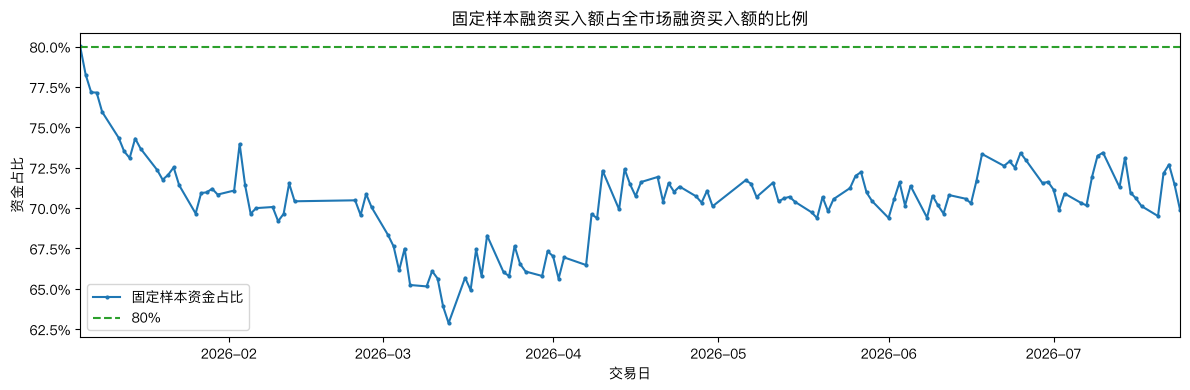

In [4]:
coverage = calculate_sample_coverage(margin, sample)
coverage.to_parquet(DERIVED / 'sample_coverage.parquet', index=False)

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(coverage.trade_date, coverage.sample_coverage, marker='o', markersize=2, label='固定样本资金占比')
ax.axhline(0.8, color='tab:green', ls='--', label='80%')
ax.yaxis.set_major_formatter(PercentFormatter(1))
ax.set_xlim(coverage.trade_date.min(), coverage.trade_date.max())
ax.set_title('固定样本融资买入额占全市场融资买入额的比例')
ax.set_xlabel('交易日')
ax.set_ylabel('资金占比')
ax.legend()
plt.tight_layout()
plt.show()

,样本证券数,有行情证券数,无行情证券数
0,1014,1014,0


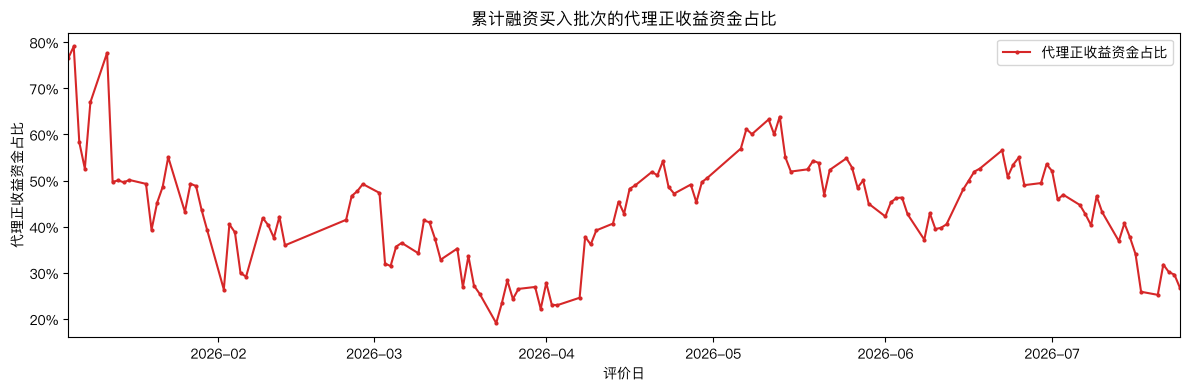

,评价日,累计批次融资买入额,代理正收益批次融资买入额,代理正收益资金占比,代理正收益批次数,全部批次数
129,2026-07-20 00:00:00,"24,699,855,692,640","6,235,187,538,330",25.24%,29738,131162
130,2026-07-21 00:00:00,"24,892,472,163,405","7,916,144,943,639",31.80%,35562,132165
131,2026-07-22 00:00:00,"25,071,519,666,126","7,564,604,027,098",30.17%,34740,133168
132,2026-07-23 00:00:00,"25,207,535,012,137","7,465,180,926,701",29.61%,36861,134170
133,2026-07-24 00:00:00,"25,321,573,980,654","6,767,892,833,089",26.73%,31286,135171


In [5]:
sample_keys = sample[['exchange', 'security_code']].drop_duplicates()
positions = build_positions(margin, sample, prices)
missing_price_keys = sample_keys.merge(prices[['exchange', 'security_code']].drop_duplicates(), on=['exchange', 'security_code'], how='left', indicator=True)
missing_price_keys = missing_price_keys.loc[missing_price_keys['_merge'].eq('left_only')].drop(columns='_merge')
display(pd.DataFrame({'样本证券数': [len(sample_keys)], '有行情证券数': [len(sample_keys) - len(missing_price_keys)], '无行情证券数': [len(missing_price_keys)]}))

profitability = calculate_cumulative_profitability(positions, prices)
profitability.to_parquet(DERIVED / 'profit_ratio.parquet', index=False)

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(profitability.evaluation_date, profitability.profit_ratio, color='tab:red', marker='o', markersize=2, label='代理正收益资金占比')
ax.yaxis.set_major_formatter(PercentFormatter(1))
ax.set_xlim(profitability.evaluation_date.min(), profitability.evaluation_date.max())
ax.set_title('累计融资买入批次的代理正收益资金占比')
ax.set_xlabel('评价日')
ax.set_ylabel('代理正收益资金占比')
ax.legend()
plt.tight_layout()
plt.show()
cumulative_display = profitability.tail().rename(columns={
    'evaluation_date': '评价日', 'cumulative_entry_amount': '累计批次融资买入额',
    'profitable_amount': '代理正收益批次融资买入额', 'profit_ratio': '代理正收益资金占比',
    'profitable_batch_count': '代理正收益批次数', 'total_batch_count': '全部批次数',
})
display(cumulative_display.style.format({'累计批次融资买入额': '{:,.0f}', '代理正收益批次融资买入额': '{:,.0f}', '代理正收益资金占比': '{:.2%}'}))

## 首日融资买入额分组的累计收益代理

分组仅由研究起点日（2026-01-05）的全市场融资买入额决定：最高 10 只组与中位附近 10 只组。此后成员不变；每个评价日累计该日及以前的有效融资买入批次，并沿用报告开头的成交均价与持续持有假设。行业总体仅统计固定 80% 样本中、与分组证券同业的股票。

,融资买入额分组,首日融资买入额排名,交易所,证券代码,证券简称,证券类型,行业,行业分类,首日融资买入额
0,最高 10 只组,1,SZSE,300476,胜宏科技,股票,C39计算机、通信和其他电子设备制造业,证监会行业分类,"3,627,252,152"
1,最高 10 只组,2,SZSE,002050,三花智控,股票,C34通用设备制造业,证监会行业分类,"2,780,581,343"
2,最高 10 只组,3,SZSE,300308,中际旭创,股票,C39计算机、通信和其他电子设备制造业,证监会行业分类,"2,773,718,089"
3,最高 10 只组,4,SZSE,300502,新易盛,股票,C39计算机、通信和其他电子设备制造业,证监会行业分类,"2,370,988,542"
4,最高 10 只组,5,SSE,600118,中国卫星,股票,C39计算机、通信和其他电子设备制造业,证监会行业分类,"2,135,286,965"
5,最高 10 只组,6,SZSE,300058,蓝色光标,股票,L72商务服务业,证监会行业分类,"2,073,296,785"
6,最高 10 只组,7,SZSE,300136,信维通信,股票,C39计算机、通信和其他电子设备制造业,证监会行业分类,"1,983,397,856"
7,最高 10 只组,8,SSE,688981,中芯国际,股票,C39计算机、通信和其他电子设备制造业,证监会行业分类,"1,784,842,495"
8,最高 10 只组,9,SZSE,300274,阳光电源,股票,C38电气机械和器材制造业,证监会行业分类,"1,684,477,748"
9,最高 10 只组,10,SZSE,300059,东方财富,股票,J67资本市场服务,证监会行业分类,"1,654,945,507"


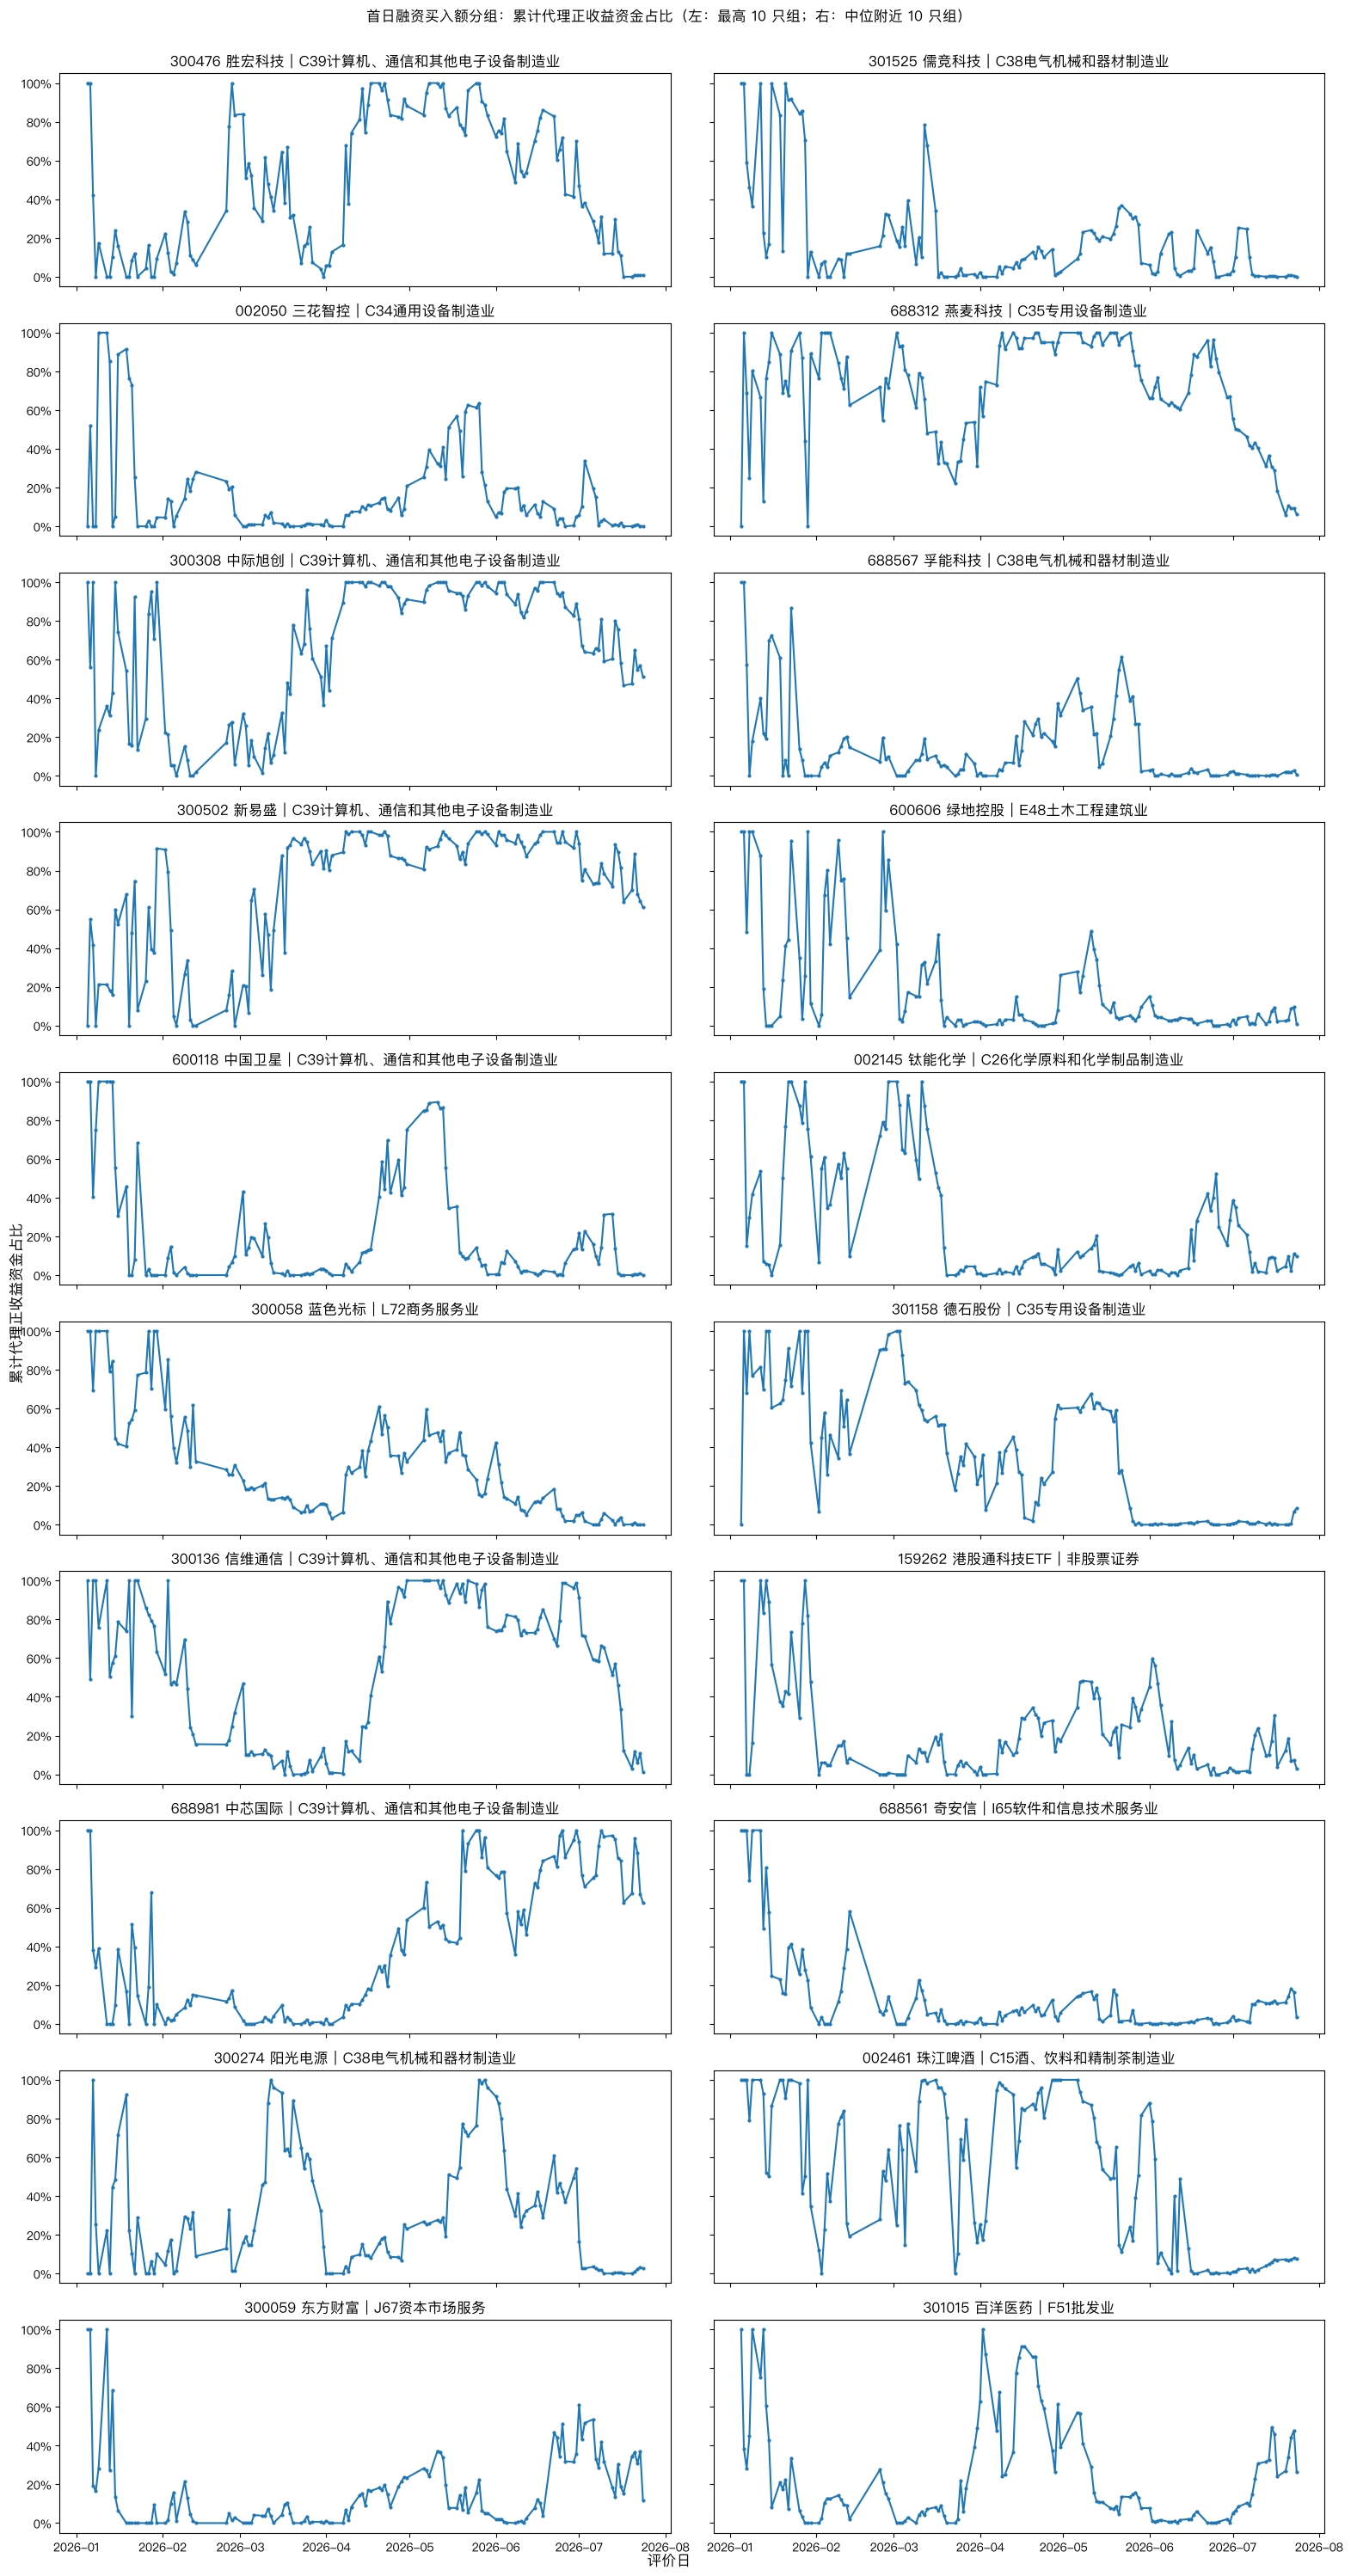

,industry,industry_classification,样本股票数量
0,C15酒、饮料和精制茶制造业,证监会行业分类,3
1,C26化学原料和化学制品制造业,证监会行业分类,39
2,C34通用设备制造业,证监会行业分类,38
3,C35专用设备制造业,证监会行业分类,58
4,C38电气机械和器材制造业,证监会行业分类,61
5,C39计算机、通信和其他电子设备制造业,证监会行业分类,249
6,E48土木工程建筑业,证监会行业分类,6
7,F51批发业,证监会行业分类,9
8,I65软件和信息技术服务业,证监会行业分类,92
9,J67资本市场服务,证监会行业分类,26


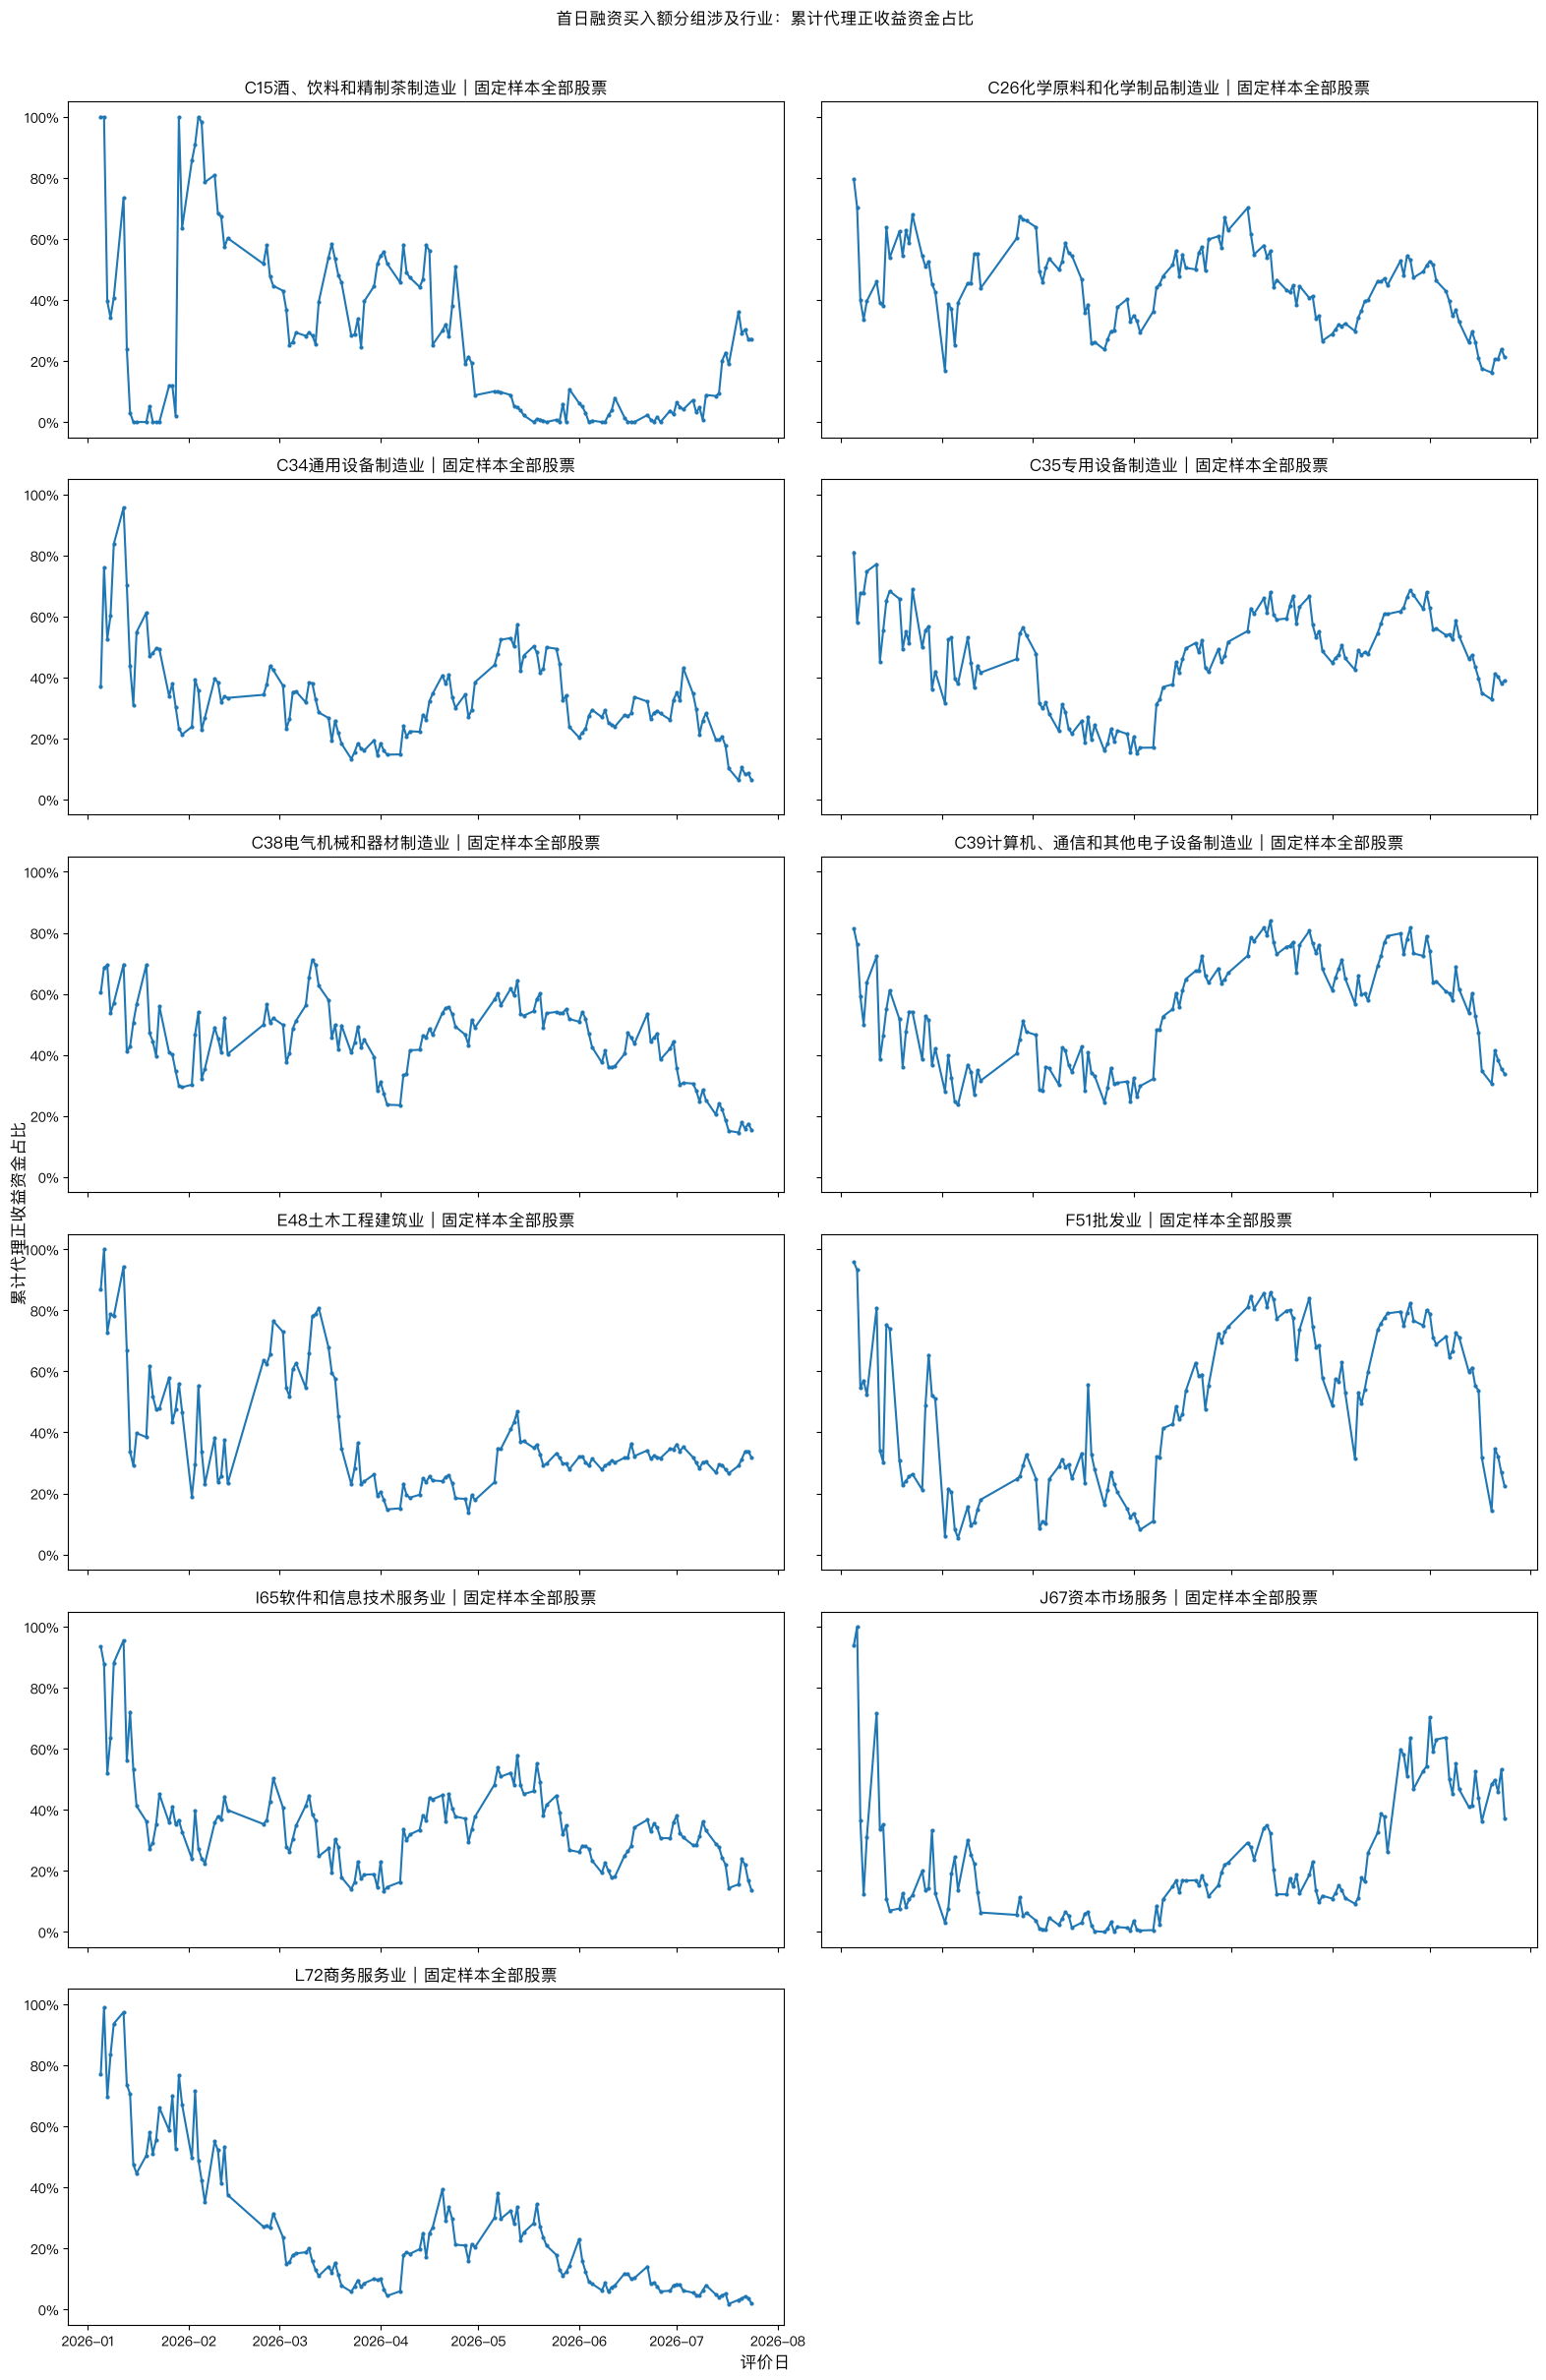

In [6]:
tier_metadata = tiers.merge(
    prepare_security_metadata(tiers, industries, basics),
    on=['exchange', 'security_code'],
    how='left',
    validate='many_to_one',
)
if tier_metadata.security_type.isna().any():
    raise RuntimeError('首日融资买入额分组证券存在未匹配的 BaoStock 基础信息。')

group_names = {'highest': '最高 10 只组', 'median': '中位附近 10 只组'}
tier_display = tier_metadata.assign(融资买入额分组=lambda data: data['tier'].map(group_names)).sort_values(['tier', 'first_day_rank']).loc[:, [
    '融资买入额分组', 'first_day_rank', 'exchange', 'security_code', 'security_name', 'security_type',
    'industry', 'industry_classification', 'financing_buy_amount',
]].rename(columns={'first_day_rank': '首日融资买入额排名', 'exchange': '交易所', 'security_code': '证券代码', 'security_name': '证券简称', 'security_type': '证券类型', 'industry': '行业', 'industry_classification': '行业分类', 'financing_buy_amount': '首日融资买入额'})
tier_display['证券类型'] = tier_display['证券类型'].map({'stock': '股票', 'etf': 'ETF', 'convertible_bond': '可转债', 'index': '指数'}).fillna(tier_display['证券类型'])
display(tier_display.style.format({'首日融资买入额': '{:,.0f}'}))

tier_profitability = calculate_tier_profitability(margin, tiers, tier_prices, tier_metadata)
tier_profitability.to_parquet(DERIVED / 'first_day_financing_tier_profitability.parquet', index=False)

fig, axes = plt.subplots(10, 2, figsize=(16, 30), sharex=True, sharey=True)
for column, tier in enumerate(['highest', 'median']):
    group = tier_metadata.loc[tier_metadata.tier.eq(tier)].sort_values('first_day_rank')
    for axis, security in zip(axes[:, column], group.itertuples(index=False), strict=False):
        series = tier_profitability.loc[
            tier_profitability.tier.eq(tier)
            & tier_profitability.exchange.eq(security.exchange)
            & tier_profitability.security_code.eq(security.security_code)
        ]
        axis.plot(series.evaluation_date, series.cumulative_profit_ratio, marker='o', markersize=2)
        axis.yaxis.set_major_formatter(PercentFormatter(1))
        axis.set_title(f'{security.security_code} {security.security_name}｜{security.industry}')
fig.suptitle('首日融资买入额分组：累计代理正收益资金占比（左：最高 10 只组；右：中位附近 10 只组）', y=1.002)
fig.supxlabel('评价日')
fig.supylabel('累计代理正收益资金占比')
plt.tight_layout()
plt.show()

fixed_industry_metadata = prepare_security_metadata(sample, industries)
tier_industry_profitability, industry_summary = calculate_industry_cumulative_profitability(
    positions, prices, fixed_industry_metadata, tier_metadata
)
tier_industry_profitability.to_parquet(
    DERIVED / 'first_day_financing_tier_industry_profitability.parquet', index=False
)
display(industry_summary)

ncols = 2
nrows = (len(industry_summary) + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(16, 4 * nrows), sharex=True, sharey=True)
axes = axes.ravel()
for axis, industry in zip(axes, industry_summary.itertuples(index=False), strict=False):
    series = tier_industry_profitability.loc[
        tier_industry_profitability.industry.eq(industry.industry)
        & tier_industry_profitability.industry_classification.eq(industry.industry_classification)
    ]
    axis.plot(series.evaluation_date, series.cumulative_profit_ratio, marker='o', markersize=2)
    axis.yaxis.set_major_formatter(PercentFormatter(1))
    axis.set_title(f'{industry.industry}｜固定样本全部股票')
for axis in axes[len(industry_summary):]:
    axis.set_visible(False)
fig.suptitle('首日融资买入额分组涉及行业：累计代理正收益资金占比', y=1.01)
fig.supxlabel('评价日')
fig.supylabel('累计代理正收益资金占比')
plt.tight_layout()
plt.show()


## 探索性样本内分析：60 日滚动融资买入批次收益代理

固定首日 80% 样本不变。每个评价日仅统计最近 60 个交易日内的融资买入批次；前 59 个交易日使用已有窗口展示，但不参与证券排名。窗口内批次仍假设持续持有至评价日，沿用报告开头的收益代理口径。

研究预先排除 `511360`（短融 ETF）和 `511520`（政金债 ETF），原因是本节不研究低风险债券；该清单同时用于高、低两组。其他证券均保留，不因 ETF 身份被排除。

证券分组使用整个样本期的平均滚动结果，后续图表又回看同一期间，因此本节仅是样本内探索性描述，不构成样本外验证、预测结论或选股策略。

In [7]:
WINDOW_DAYS = 60
rolling_security, rolling_overall = calculate_rolling_profitability(positions, prices, WINDOW_DAYS)
rolling_security.to_parquet(DERIVED / 'rolling_profitability.parquet', index=False)
rolling_overall.to_parquet(DERIVED / 'rolling_profitability_overall.parquet', index=False)
rolling_display = rolling_overall.tail().rename(columns={
    'evaluation_date': '评价日', 'window_start_date': '窗口起始日',
    'window_trading_days': '窗口交易日数', 'window_margin_purchase': '窗口批次融资买入额',
    'profitable_amount': '代理正收益批次融资买入额', 'rolling_profit_ratio': '代理正收益资金占比',
    'is_full_window': '是否完整60日窗口',
})
display(rolling_display.style.format({'窗口批次融资买入额': '{:,.0f}', '代理正收益批次融资买入额': '{:,.0f}', '代理正收益资金占比': '{:.2%}'}))

,评价日,窗口起始日,窗口交易日数,窗口批次融资买入额,代理正收益批次融资买入额,代理正收益资金占比,是否完整60日窗口
129,2026-07-20 00:00:00,2026-04-22 00:00:00,60,"12,682,383,524,888","2,483,051,487,622",19.58%,True
130,2026-07-21 00:00:00,2026-04-23 00:00:00,60,"12,687,160,557,772","3,650,916,062,508",28.78%,True
131,2026-07-22 00:00:00,2026-04-24 00:00:00,60,"12,665,805,695,242","3,323,838,005,278",26.24%,True
132,2026-07-23 00:00:00,2026-04-27 00:00:00,60,"12,617,601,583,883","3,126,801,159,068",24.78%,True
133,2026-07-24 00:00:00,2026-04-28 00:00:00,60,"12,547,044,426,924","2,649,538,810,667",21.12%,True


In [8]:
security_metadata = prepare_security_metadata(sample, industries)
excluded_low_risk_bond_etfs = {'511360': '短融ETF', '511520': '政金债ETF'}
selection_scope_review = pd.DataFrame([{
    '候选规则': '排除两只低风险债券ETF（高、低组对称）',
    '固定样本证券数': len(security_metadata),
    '排除证券': '；'.join(f'{code} {name}' for code, name in excluded_low_risk_bond_etfs.items()),
    '候选证券数': int((~security_metadata.security_code.isin(excluded_low_risk_bond_etfs)).sum()),
    '排除证券数': len(excluded_low_risk_bond_etfs),
}])
display(selection_scope_review)
selection, profit_ratio_high, profit_ratio_low, return_high, return_low = select_rolling_securities(
    rolling_security, security_metadata, excluded_security_codes=set(excluded_low_risk_bond_etfs), size=10
)
selection.to_parquet(DERIVED / 'rolling_profitability_selection.parquet', index=False)

selection_columns = ['security_code', 'security_name', 'security_type', 'industry', 'industry_classification', 'mean_profit_ratio', 'mean_weighted_return']
selection_column_names = {'security_code': '证券代码', 'security_name': '证券简称', 'security_type': '证券类型', 'industry': '行业', 'industry_classification': '行业分类', 'mean_profit_ratio': '平均代理正收益资金占比', 'mean_weighted_return': '平均融资买入额加权代理收益'}
security_type_names = {'stock': '股票', 'etf': 'ETF', 'convertible_bond': '可转债', 'index': '指数'}
ratio_selection_display = pd.concat({'代理正收益占比高前 10': profit_ratio_high[selection_columns], '代理正收益占比低后 10': profit_ratio_low[selection_columns]}, names=['筛选结果']).rename(columns=selection_column_names)
return_selection_display = pd.concat({'加权代理收益为正且占比高前 10': return_high[selection_columns], '加权代理收益为负且占比低后 10': return_low[selection_columns]}, names=['筛选结果']).rename(columns=selection_column_names)
ratio_selection_display['证券类型'] = ratio_selection_display['证券类型'].map(security_type_names).fillna(ratio_selection_display['证券类型'])
return_selection_display['证券类型'] = return_selection_display['证券类型'].map(security_type_names).fillna(return_selection_display['证券类型'])
selection_formats = {'平均代理正收益资金占比': '{:.2%}', '平均融资买入额加权代理收益': '{:.2%}'}
display(ratio_selection_display.style.format(selection_formats))
display(return_selection_display.style.format(selection_formats))

comparison = compare_rolling_selection(selection, profit_ratio_high, profit_ratio_low, return_high, return_low)
comparison_display = comparison.assign(分组=lambda data: data['分组'].map({'high': '代理正收益占比高组', 'low': '代理正收益占比低组'})).rename(columns={'分组': '代理正收益占比分组', '状态': '加入加权代理收益方向筛选后的变化', 'exchange': '交易所', 'security_code': '证券代码', 'security_name': '证券简称', 'security_type': '证券类型', 'industry': '行业', 'industry_classification': '行业分类'})
comparison_display['证券类型'] = comparison_display['证券类型'].map(security_type_names).fillna(comparison_display['证券类型'])
display(comparison_display)

,候选规则,固定样本证券数,排除证券,候选证券数,排除证券数
0,排除两只低风险债券ETF（高、低组对称）,1014,511360 短融ETF；511520 政金债ETF,1012,2


,代理正收益占比分组,加入加权代理收益方向筛选后的变化,交易所,证券代码,证券简称,证券类型,行业,行业分类
0,代理正收益占比高组,重合,SSE,688072,拓荆科技,股票,C35专用设备制造业,证监会行业分类
1,代理正收益占比高组,重合,SSE,688141,杰华特,股票,I65软件和信息技术服务业,证监会行业分类
2,代理正收益占比高组,重合,SSE,688200,华峰测控,股票,C35专用设备制造业,证监会行业分类
3,代理正收益占比高组,重合,SSE,688498,源杰科技,股票,C39计算机、通信和其他电子设备制造业,证监会行业分类
4,代理正收益占比高组,重合,SSE,688630,芯碁微装,股票,C35专用设备制造业,证监会行业分类
5,代理正收益占比高组,重合,SZSE,002384,东山精密,股票,C39计算机、通信和其他电子设备制造业,证监会行业分类
6,代理正收益占比高组,重合,SZSE,300502,新易盛,股票,C39计算机、通信和其他电子设备制造业,证监会行业分类
7,代理正收益占比高组,重合,SZSE,300604,长川科技,股票,C35专用设备制造业,证监会行业分类
8,代理正收益占比高组,重合,SZSE,300661,圣邦股份,股票,C39计算机、通信和其他电子设备制造业,证监会行业分类
9,代理正收益占比高组,重合,SZSE,301377,鼎泰高科,股票,C33金属制品业,证监会行业分类


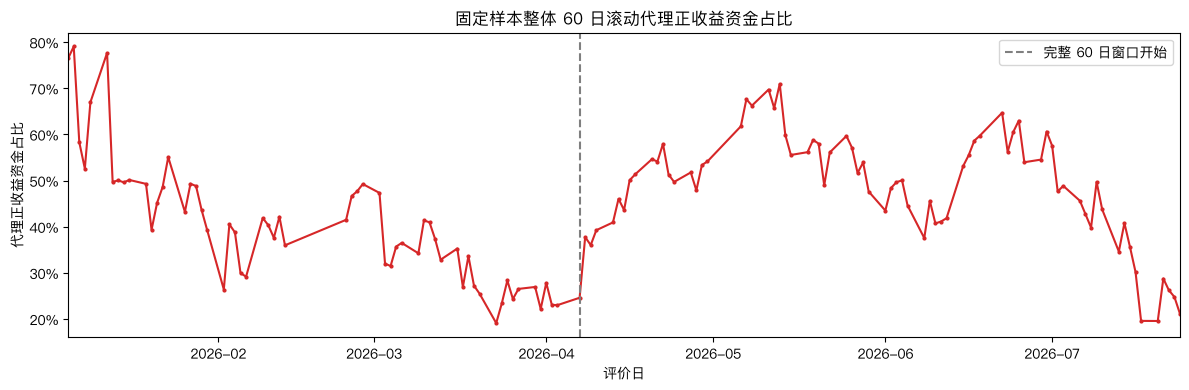

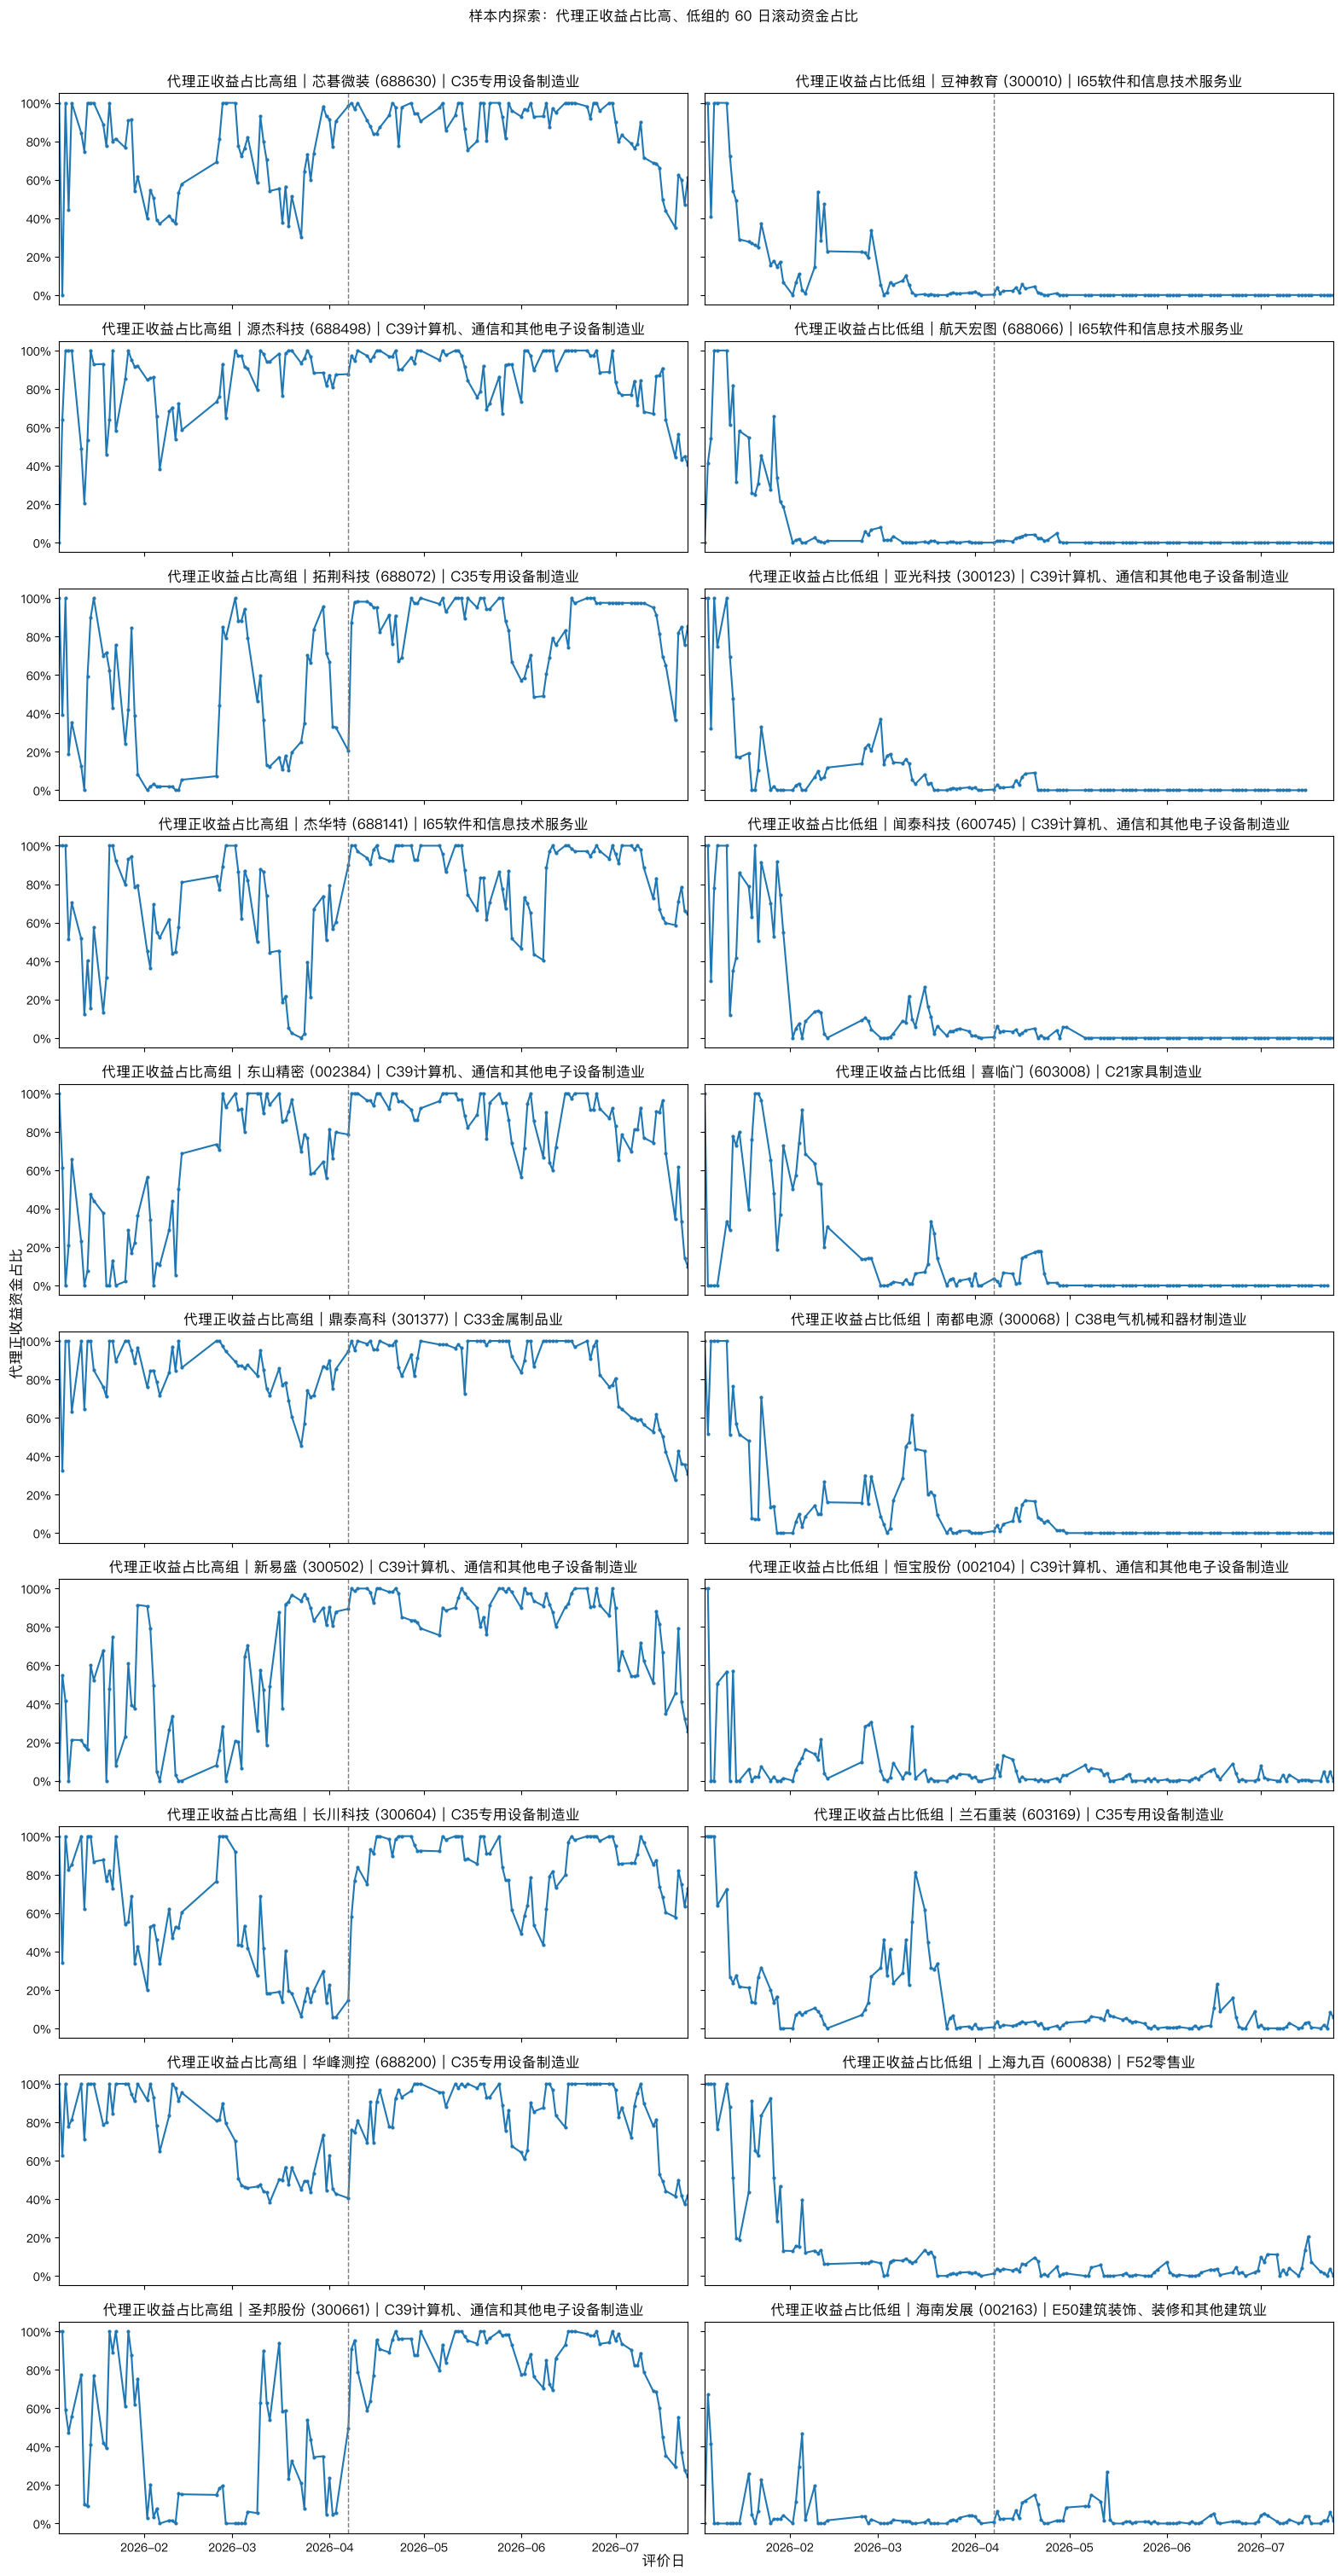

In [9]:
full_window_start = rolling_overall.loc[rolling_overall.is_full_window, 'evaluation_date'].iloc[0]
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(rolling_overall.evaluation_date, rolling_overall.rolling_profit_ratio, color='tab:red', marker='o', markersize=2)
ax.axvline(full_window_start, color='tab:gray', ls='--', label='完整 60 日窗口开始')
ax.yaxis.set_major_formatter(PercentFormatter(1))
ax.set_xlim(rolling_overall.evaluation_date.min(), rolling_overall.evaluation_date.max())
ax.set_title('固定样本整体 60 日滚动代理正收益资金占比')
ax.set_xlabel('评价日')
ax.set_ylabel('代理正收益资金占比')
ax.legend()
plt.tight_layout()
plt.show()

selected_high = selection.loc[selection.selected_group.eq('high')].nlargest(10, 'mean_profit_ratio').reset_index(drop=True)
selected_low = selection.loc[selection.selected_group.eq('low')].nsmallest(10, 'mean_profit_ratio').reset_index(drop=True)
fig, axes = plt.subplots(10, 2, figsize=(16, 30), sharex=True, sharey=True)
for row_index, (group, title, selected) in enumerate([('high', '代理正收益占比高组', selected_high), ('low', '代理正收益占比低组', selected_low)]):
    for panel_index, security in enumerate(selected.itertuples(index=False)):
        ax = axes[panel_index, row_index]
        series = rolling_security.loc[
            rolling_security.exchange.eq(security.exchange) & rolling_security.security_code.eq(security.security_code)
        ]
        ax.plot(series.evaluation_date, series.rolling_profit_ratio, marker='o', markersize=2)
        ax.axvline(full_window_start, color='tab:gray', ls='--', linewidth=1)
        ax.yaxis.set_major_formatter(PercentFormatter(1))
        ax.set_title(f'{title}｜{security.security_name} ({security.security_code})｜{security.industry}')
        ax.set_xlim(rolling_overall.evaluation_date.min(), rolling_overall.evaluation_date.max())
fig.suptitle('样本内探索：代理正收益占比高、低组的 60 日滚动资金占比', y=1.01)
fig.supxlabel('评价日')
fig.supylabel('代理正收益资金占比')
plt.tight_layout()
plt.show()

## 探索性样本内筛选所涉及行业的收益代理

以样本内代理正收益占比高、低组涉及的行业为范围，纳入固定样本中该行业的全部股票；每个行业的代理正收益资金占比按行业内代理收益大于 0 的批次融资买入额之和除以行业内全部批次融资买入额之和计算。行业范围同样由整个样本期结果事后确定，只用于探索性描述。

,industry,industry_classification,样本股票数量
0,C21家具制造业,证监会行业分类,1
1,C33金属制品业,证监会行业分类,17
2,C35专用设备制造业,证监会行业分类,58
3,C38电气机械和器材制造业,证监会行业分类,61
4,C39计算机、通信和其他电子设备制造业,证监会行业分类,249
5,E50建筑装饰、装修和其他建筑业,证监会行业分类,1
6,F52零售业,证监会行业分类,8
7,I65软件和信息技术服务业,证监会行业分类,92


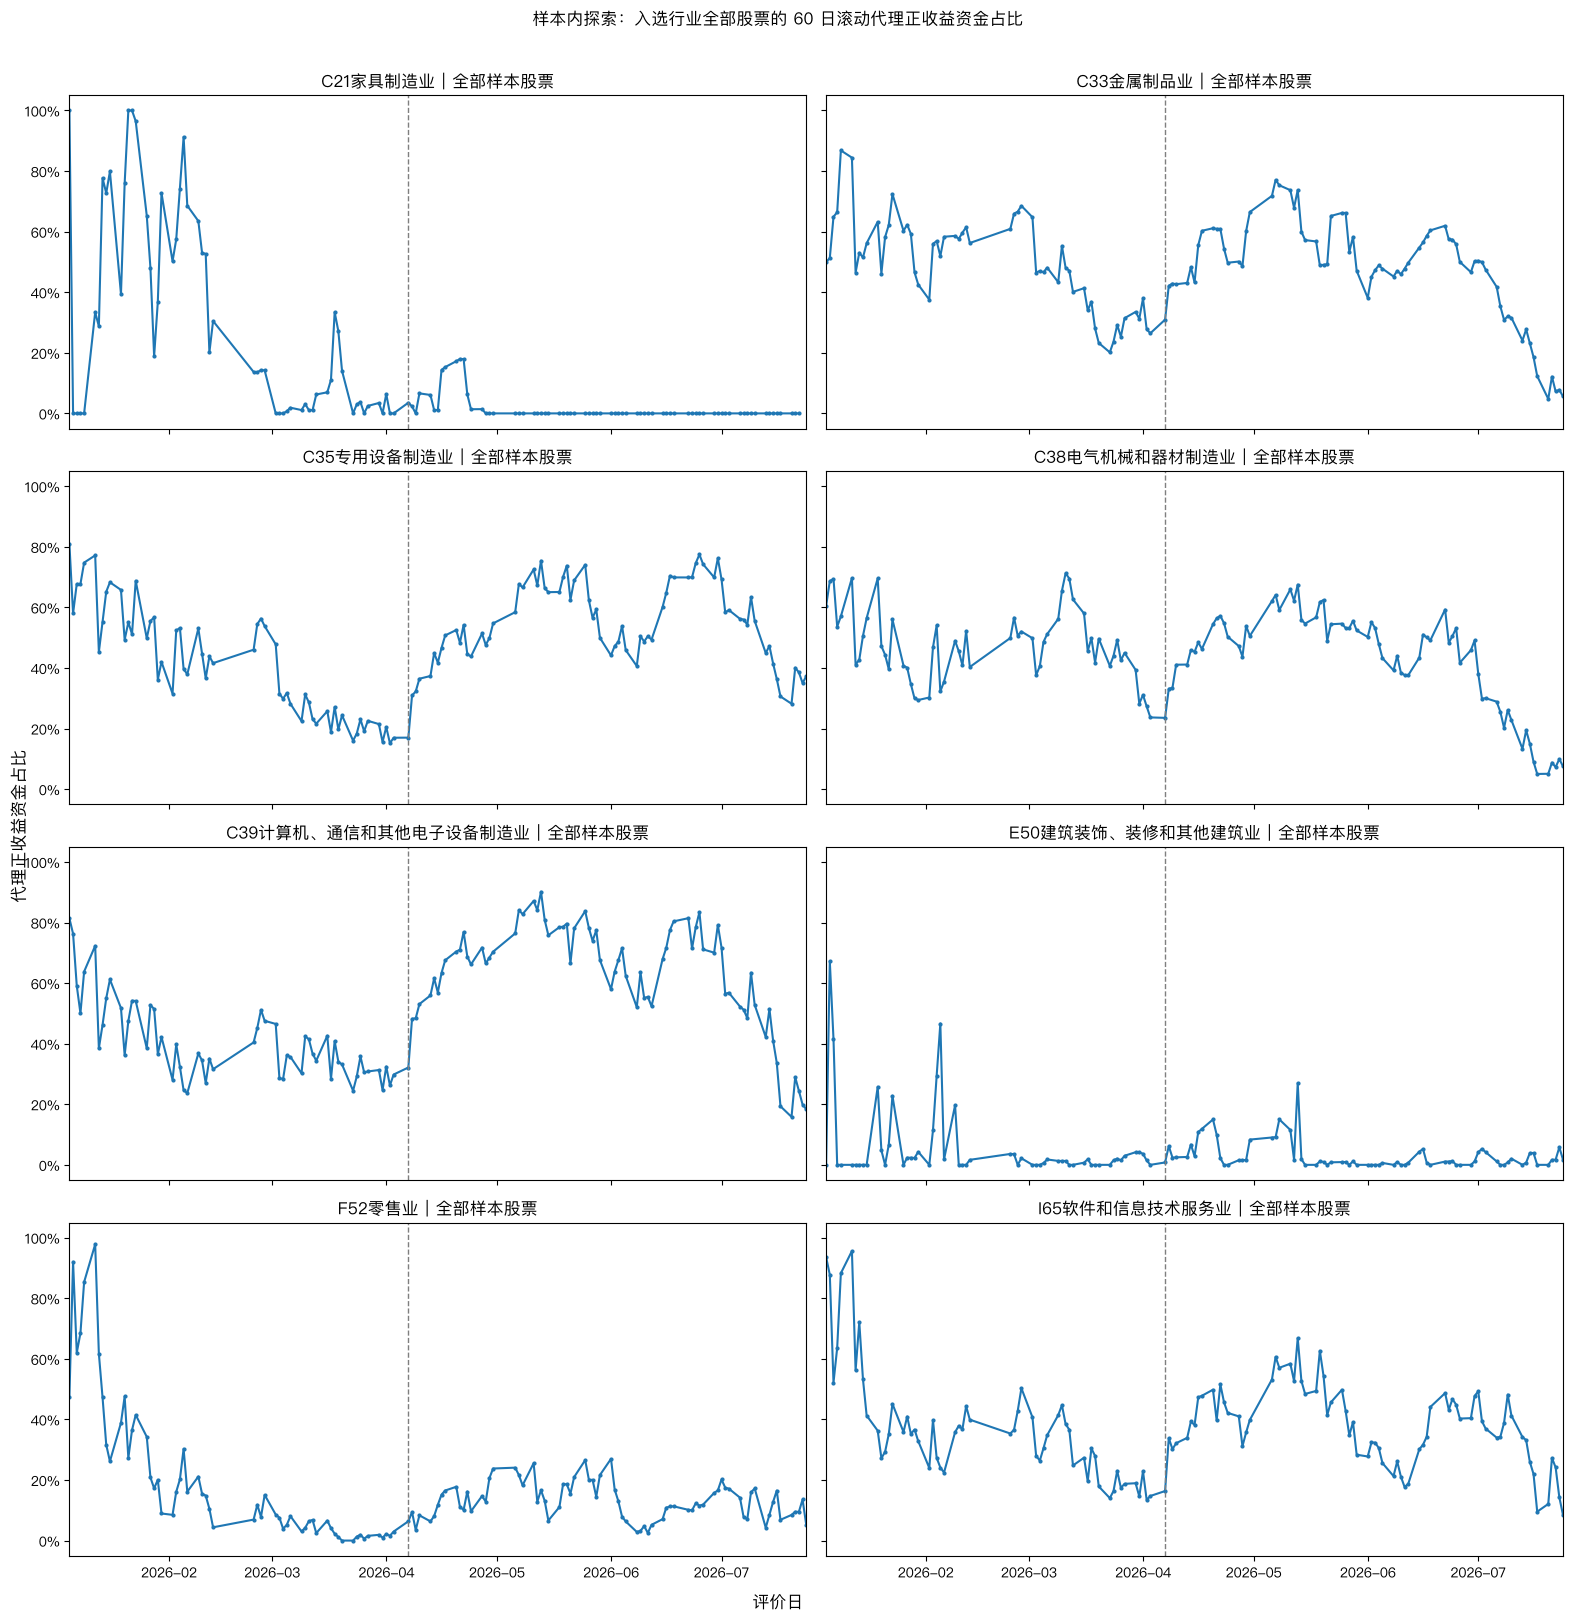

In [10]:
industry_rolling, industry_scope, industry_summary = calculate_rolling_industry_profitability(
    rolling_security, selection, security_metadata
)
industry_rolling.to_parquet(DERIVED / 'rolling_profitability_by_industry.parquet', index=False)
display(industry_summary)

ncols = 2
nrows = (len(industry_scope) + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(16, 4 * nrows), sharex=True, sharey=True)
axes = axes.ravel()
for axis, industry in zip(axes, industry_scope.itertuples(index=False), strict=False):
    series = industry_rolling.loc[
        industry_rolling.industry.eq(industry.industry)
        & industry_rolling.industry_classification.eq(industry.industry_classification)
    ]
    axis.plot(series.evaluation_date, series.rolling_profit_ratio, marker='o', markersize=2)
    axis.axvline(full_window_start, color='tab:gray', ls='--', linewidth=1)
    axis.yaxis.set_major_formatter(PercentFormatter(1))
    axis.set_xlim(rolling_overall.evaluation_date.min(), rolling_overall.evaluation_date.max())
    axis.set_title(f'{industry.industry}｜全部样本股票')
for axis in axes[len(industry_scope):]:
    axis.set_visible(False)
fig.suptitle('样本内探索：入选行业全部股票的 60 日滚动代理正收益资金占比', y=1.01)
fig.supxlabel('评价日')
fig.supylabel('代理正收益资金占比')
plt.tight_layout()
plt.show()